<a href="https://colab.research.google.com/github/emrizky1/PCVK_Ganjil_2026/blob/main/Week_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [80]:
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np
import math
import os
import glob

In [81]:
import sys, platform, hashlib, datetime, zoneinfo

NAMA = 'Muhammad Rizki'
NIM = '244107020140'

N = int(NIM[-3:])

PARAM = {
    'bins': 2 ** ((N % 4) + 3),
    'clip': round(1.0 + (N % 5) * 0.5, 1),
    'tile': (N % 4) + 2,
    'L': 2 ** ((N % 3) + 1),
}

waktu = datetime.datetime.now(
    zoneinfo.ZoneInfo('Asia/Jakarta')
)

print('NAMA :', NAMA)
print('NIM :', NIM, '| N =', N)

for k, v in PARAM.items():
    print('%-6s :' % k, v)

print(
    'WAKTU :',
    waktu.strftime('%Y-%m-%d %H:%M:%S %Z')
)

print(
    'SISTEM :',
    sys.version.split()[0],
    platform.platform()
)

kunci = NIM + '|' + waktu.strftime('%Y-%m-%d')

print(
    'TOKEN :',
    hashlib.sha256(kunci.encode()).hexdigest()[:16]
)

NAMA : Muhammad Rizki
NIM : 244107020140 | N = 140
bins   : 8
clip   : 1.0
tile   : 2
L      : 8
WAKTU : 2026-09-30 16:48:27 WIB
SISTEM : 3.13.15 Linux-6.6.122+-x86_64-with-glibc2.39
TOKEN : ca03cdc10dad7d78


<BarContainer object of 256 artists>

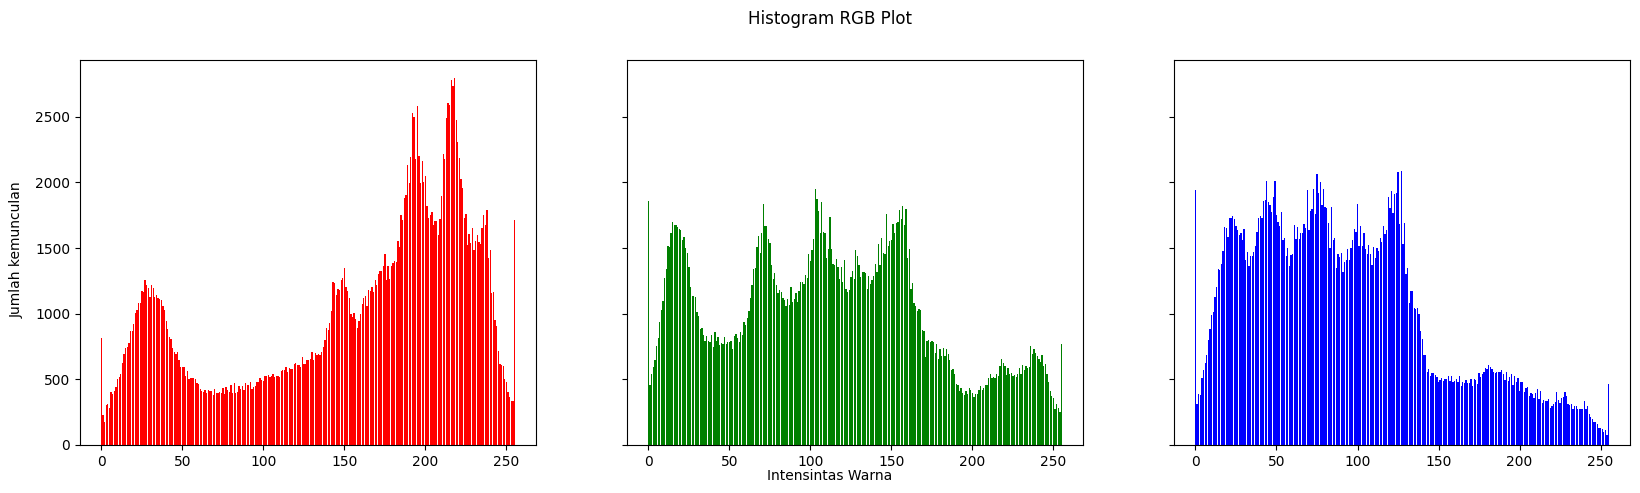

In [82]:
img = cv.imread('/content/drive/MyDrive/pcvk_2026/Images/lena.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img)
names = np.arange(256)

red = [0]*256
green = [0]*256
blue = [0]*256

for y in range(0, height):
  for x in range(0, width):
    red[img[y][x][0]] += 1
    green[img[y][x][1]] += 1
    blue[img[y][x][2]] += 1


names = np.arange(256)
fig, axs = plt.subplots(1, 3, figsize=[20,5], sharex=True, sharey=True)
fig.suptitle('Histogram RGB Plot')
fig.text(0.09, 0.5, 'Jumlah kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensintas Warna', ha='center')
axs[0].bar(names, red, color='red')
axs[1].bar(names, green, color='green')
axs[2].bar(names, blue, color='blue')

=== MAX VALUE ===

Manual vs NumPy:
Red  : 0
Green  : 0
Blue : 0

Manual vs cv.calcHist
Red  : 0.0
Green  : 0.0
Blue : 0.0

NumPy vs cv.calcHist:
Red  : 0.0
Green  : 0.0
Blue : 0.0


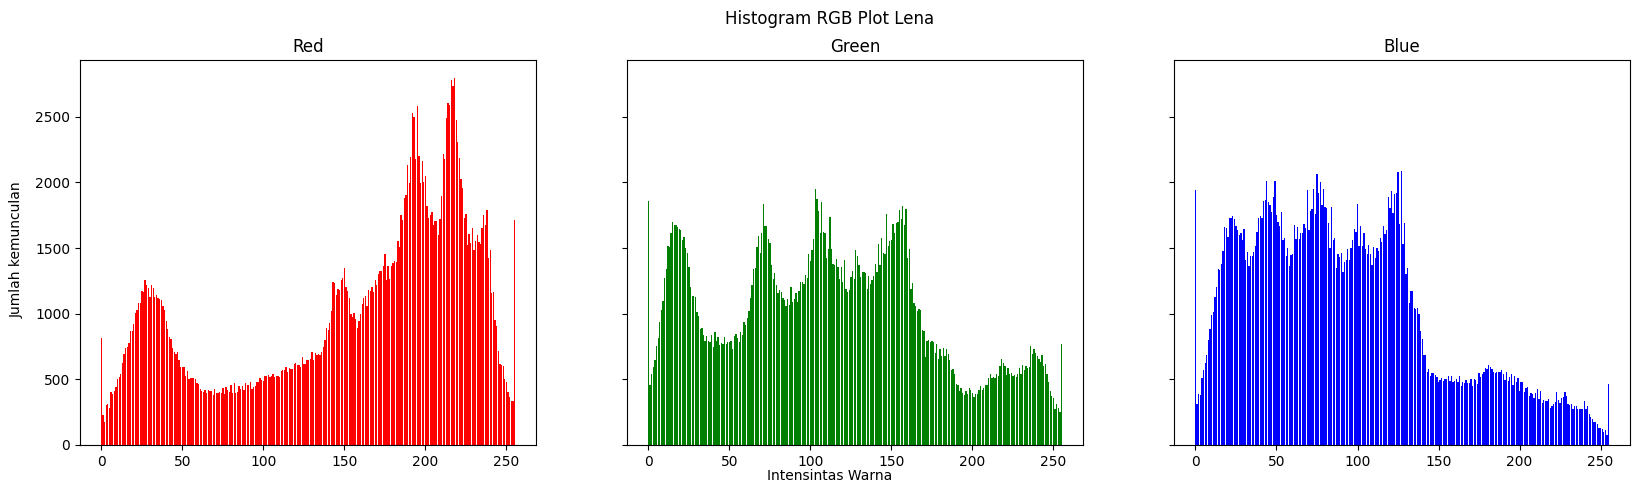

In [83]:
img = cv.imread('/content/drive/MyDrive/pcvk_2026/Images/lena.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img)
names = np.arange(256)

red = [0]*256
green = [0]*256
blue = [0]*256

for y in range(0, height):
  for x in range(0, width):
    red[img[y][x][0]] += 1
    green[img[y][x][1]] += 1
    blue[img[y][x][2]] += 1

red_np, _ = np.histogram(img[:, :, 0], bins=256, range=(0, 256))
green_np, _ = np.histogram(img[:, :, 1], bins=256, range=(0, 256))
blue_np, _ = np.histogram(img[:, :, 2], bins=256, range=(0, 256))

red_cv = cv.calcHist([img], [0], None, [256], [0, 256]).flatten()
green_cv = cv.calcHist([img], [1], None, [256], [0, 256]).flatten()
blue_cv = cv.calcHist([img], [2], None, [256], [0, 256]).flatten()

max_diff_red_np = np.max(np.abs(np.array(red) - red_np))
max_diff_green_np = np.max(np.abs(np.array(green) - green_np))
max_diff_blue_np = np.max(np.abs(np.array(blue) - blue_np))

max_diff_red_cv = np.max(np.abs(np.array(red) - red_cv))
max_diff_green_cv = np.max(np.abs(np.array(green) - green_cv))
max_diff_blue_cv = np.max(np.abs(np.array(blue) - blue_cv))

max_diff_np_cv_red = np.max(np.abs(red_np - red_cv))
max_diff_np_cv_green = np.max(np.abs(green_np - green_cv))
max_diff_np_cv_blue = np.max(np.abs(blue_np - blue_cv))

print("=== MAX VALUE ===")

print("\nManual vs NumPy:")
print("Red  :", max_diff_red_np)
print("Green  :", max_diff_green_np)
print("Blue :", max_diff_blue_np)

print("\nManual vs cv.calcHist")
print("Red  :", max_diff_red_cv)
print("Green  :", max_diff_green_cv)
print("Blue :", max_diff_blue_cv)

print("\nNumPy vs cv.calcHist:")
print("Red  :", max_diff_np_cv_red)
print("Green  :", max_diff_np_cv_green)
print("Blue :", max_diff_np_cv_blue)

fig, axs = plt.subplots(1, 3, figsize=[20, 5], sharex=True, sharey=True)

fig.suptitle('Histogram RGB Plot Lena')

fig.text(0.09, 0.5, 'Jumlah kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensintas Warna', ha='center')

axs[0].bar(names, red_np, color='red')
axs[0].set_title('Red')

axs[1].bar(names, green_np, color='green')
axs[1].set_title('Green')

axs[2].bar(names, blue_np, color='blue')
axs[2].set_title('Blue')

plt.show()

=== MAX VALUE ===

Manual vs NumPy:
Red  : 0
Green  : 0
Blue : 0

Manual vs cv.calcHist
Red  : 0.0
Green  : 0.0
Blue : 0.0

NumPy vs cv.calcHist:
Red  : 0.0
Green  : 0.0
Blue : 0.0


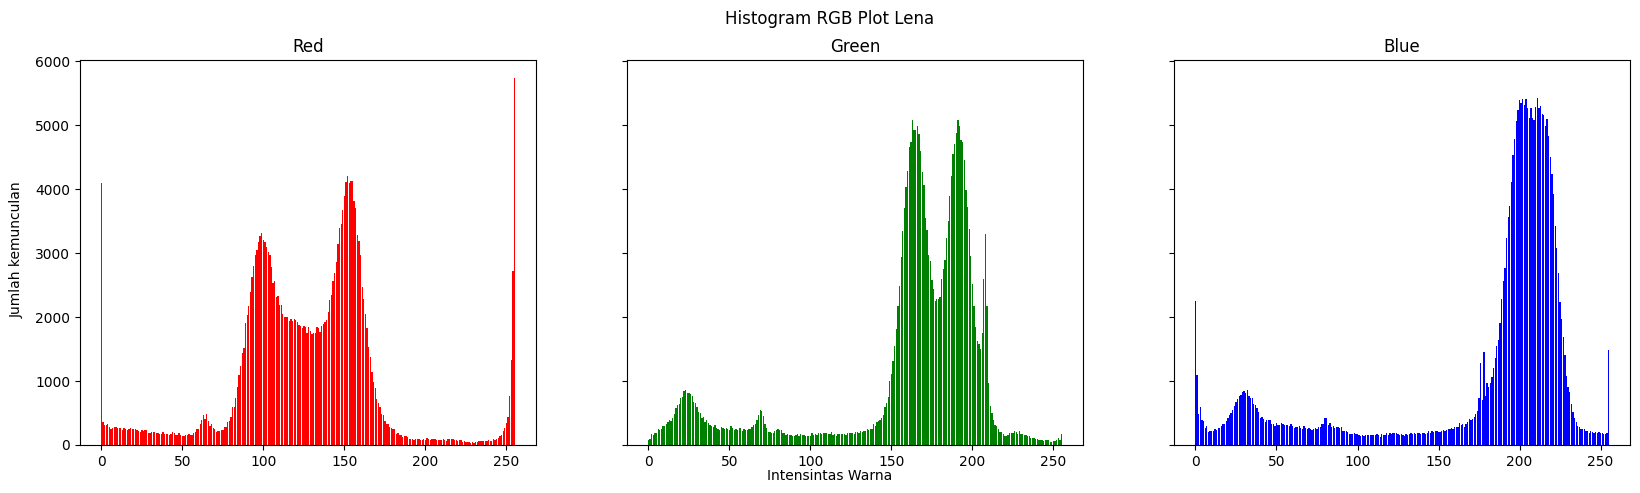

In [84]:
img = cv.imread('/content/drive/MyDrive/pcvk_2026/ktp.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img)
names = np.arange(256)

red = [0]*256
green = [0]*256
blue = [0]*256

for y in range(0, height):
  for x in range(0, width):
    red[img[y][x][0]] += 1
    green[img[y][x][1]] += 1
    blue[img[y][x][2]] += 1

red_np, _ = np.histogram(img[:, :, 0], bins=256, range=(0, 256))
green_np, _ = np.histogram(img[:, :, 1], bins=256, range=(0, 256))
blue_np, _ = np.histogram(img[:, :, 2], bins=256, range=(0, 256))

red_cv = cv.calcHist([img], [0], None, [256], [0, 256]).flatten()
green_cv = cv.calcHist([img], [1], None, [256], [0, 256]).flatten()
blue_cv = cv.calcHist([img], [2], None, [256], [0, 256]).flatten()

max_diff_red_np = np.max(np.abs(np.array(red) - red_np))
max_diff_green_np = np.max(np.abs(np.array(green) - green_np))
max_diff_blue_np = np.max(np.abs(np.array(blue) - blue_np))

max_diff_red_cv = np.max(np.abs(np.array(red) - red_cv))
max_diff_green_cv = np.max(np.abs(np.array(green) - green_cv))
max_diff_blue_cv = np.max(np.abs(np.array(blue) - blue_cv))

max_diff_np_cv_red = np.max(np.abs(red_np - red_cv))
max_diff_np_cv_green = np.max(np.abs(green_np - green_cv))
max_diff_np_cv_blue = np.max(np.abs(blue_np - blue_cv))

print("=== MAX VALUE ===")

print("\nManual vs NumPy:")
print("Red  :", max_diff_red_np)
print("Green  :", max_diff_green_np)
print("Blue :", max_diff_blue_np)

print("\nManual vs cv.calcHist")
print("Red  :", max_diff_red_cv)
print("Green  :", max_diff_green_cv)
print("Blue :", max_diff_blue_cv)

print("\nNumPy vs cv.calcHist:")
print("Red  :", max_diff_np_cv_red)
print("Green  :", max_diff_np_cv_green)
print("Blue :", max_diff_np_cv_blue)

fig, axs = plt.subplots(1, 3, figsize=[20, 5], sharex=True, sharey=True)

fig.suptitle('Histogram RGB Plot Lena')

fig.text(0.09, 0.5, 'Jumlah kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensintas Warna', ha='center')

axs[0].bar(names, red_np, color='red')
axs[0].set_title('Red')

axs[1].bar(names, green_np, color='green')
axs[1].set_title('Green')

axs[2].bar(names, blue_np, color='blue')
axs[2].set_title('Blue')

plt.show()

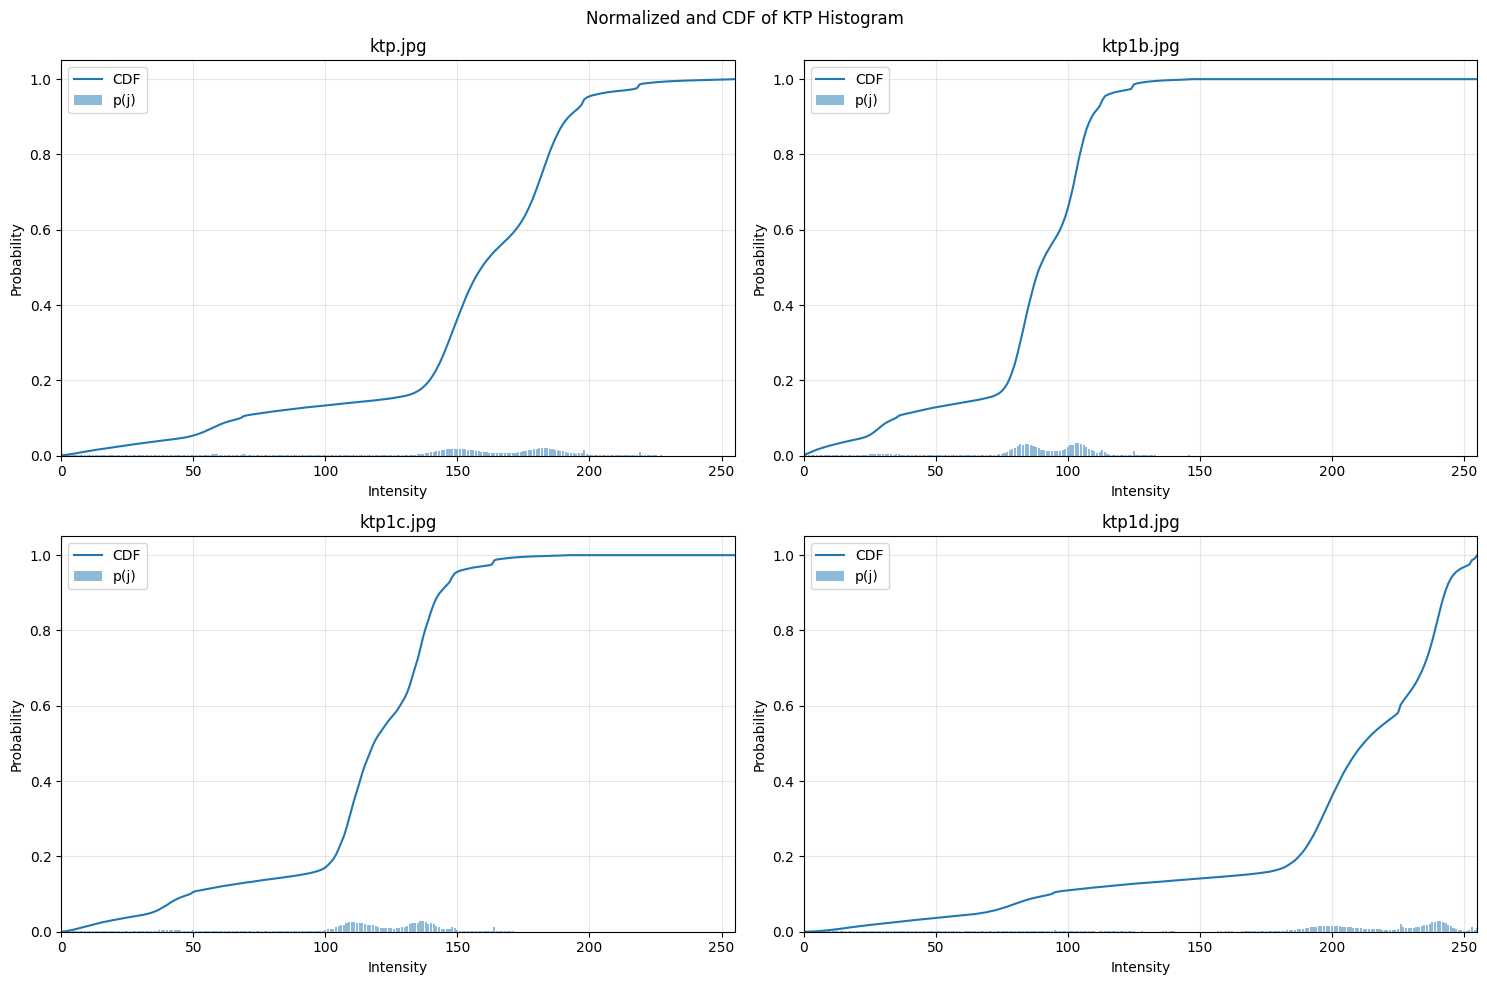

In [85]:
files = ['ktp.jpg', 'ktp1b.jpg', 'ktp1c.jpg', 'ktp1d.jpg']
fig, axs = plt.subplots(2, 2, figsize=(15, 10))

for ax, file in zip(axs.ravel(), files):
  img = cv.imread('/content/drive/MyDrive/pcvk_2026/' + file, cv.IMREAD_GRAYSCALE)

  hist = cv.calcHist([img], [0], None, [256], [0, 256]).flatten()

  p = hist / hist.sum()
  cdf = np.cumsum(p)
  intensity = np.arange(256)

  ax.bar(intensity, p, alpha=0.5, label='p(j)')
  ax.plot(intensity, cdf, label='CDF')

  ax.set_title(file)
  ax.set_xlabel('Intensity')
  ax.set_ylabel('Probability')

  ax.set_xlim(0, 255)
  ax.set_ylim(0, 1.05)

  ax.legend()
  ax.grid(alpha=0.3)

plt.suptitle('Normalized and CDF of KTP Histogram')

plt.tight_layout()
plt.show()

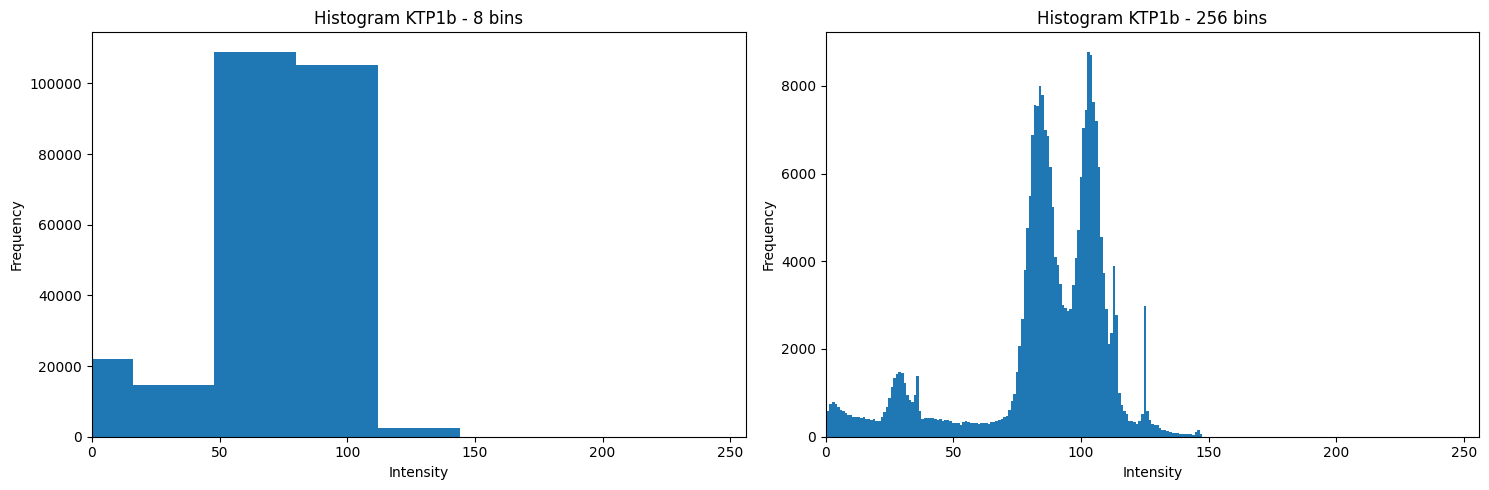

In [86]:
img = cv.imread('/content/drive/MyDrive/pcvk_2026/ktp1b.jpg', cv.IMREAD_GRAYSCALE)

bins = PARAM['bins']

hist_bins, edges_bins = np.histogram(img, bins=bins, range=(0, 256))
hist_256, edges_256 = np.histogram(img, bins=256, range=(0, 256))

fig, axs = plt.subplots(1, 2, figsize=(15, 5))

axs[0].bar(edges_bins[:-1], hist_bins, width=256 / bins)

axs[0].set_title(f'Histogram KTP1b - {bins} bins')
axs[0].set_xlabel('Intensity')
axs[0].set_ylabel('Frequency')
axs[0].set_xlim(0, 256)

axs[1].bar(edges_256[:-1], hist_256, width=1)

axs[1].set_title(f'Histogram KTP1b - 256 bins')
axs[1].set_xlabel('Intensity')
axs[1].set_ylabel('Frequency')
axs[1].set_xlim(0, 256)

plt.tight_layout()
plt.show()

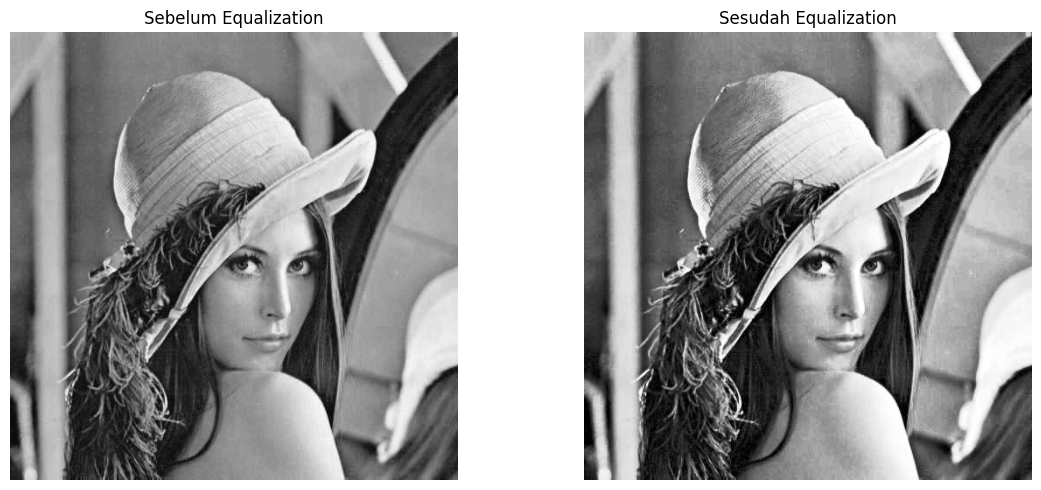

Selisih maksimum: 0


In [87]:
img = cv.imread('/content/drive/MyDrive/pcvk_2026/Images/lena_lc.jpg', cv.IMREAD_GRAYSCALE)
L = 256

hist = np.zeros(L, dtype=np.int64)

for y in range(img.shape[0]):
  for x in range(img.shape[1]):
    hist[img[y, x]] += 1

cdf = np.cumsum(hist)
cdf_normalized = cdf / img.size

K = np.round((L - 1) * cdf_normalized).astype(np.uint8)
equalized = K[img]

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

axs[0].imshow(img, cmap='gray')
axs[0].set_title('Sebelum Equalization')
axs[0].axis('off')

axs[1].imshow(equalized, cmap='gray')
axs[1].set_title('Sesudah Equalization')
axs[1].axis('off')

plt.tight_layout()
plt.show()

opencv_equalized = cv.equalizeHist(img)
max_diff = np.max(
    np.abs(
        equalized.astype(np.int16) -
        opencv_equalized.astype(np.int16)
    )
)

print("Selisih maksimum:", max_diff)

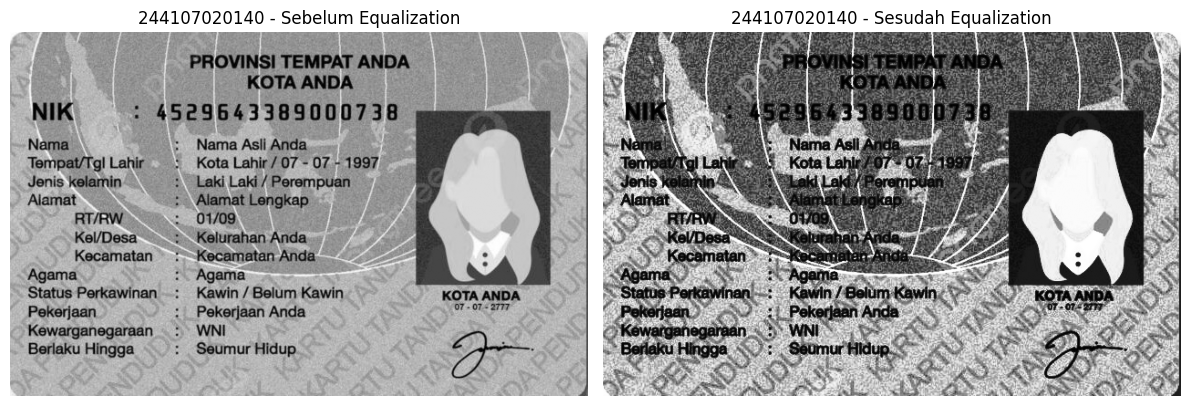

Selisih maksimum: 1


In [88]:
img = cv.imread('/content/drive/MyDrive/pcvk_2026/ktp.jpg', cv.IMREAD_GRAYSCALE)
L = 256

hist = np.zeros(L, dtype=np.int64)

for y in range(img.shape[0]):
  for x in range(img.shape[1]):
    hist[img[y, x]] += 1

cdf = np.cumsum(hist)
cdf_normalized = cdf / img.size

K = np.round((L - 1) * cdf_normalized).astype(np.uint8)
equalized = K[img]

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

axs[0].imshow(img, cmap='gray')
axs[0].set_title(f"{244107020140} - Sebelum Equalization")
axs[0].axis('off')

axs[1].imshow(equalized, cmap='gray')
axs[1].set_title(f"{244107020140} - Sesudah Equalization")
axs[1].axis('off')

plt.tight_layout()
plt.show()

opencv_equalized = cv.equalizeHist(img)
max_diff = np.max(
    np.abs(
        equalized.astype(np.int16) -
        opencv_equalized.astype(np.int16)
    )
)

print("Selisih maksimum:", max_diff)

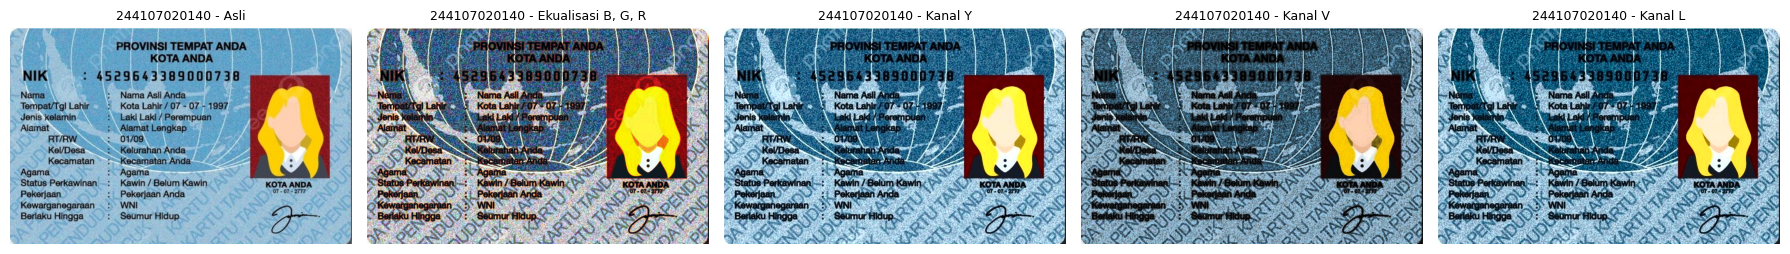

Metode                  geser Hue (der)    rerata terang
Asli                               0.00            152.3
Ekualisasi B, G, R                48.01            128.2
Kanal Y                            2.01            128.7
Kanal V                            1.07            104.6
Kanal L                            3.04            118.2
Metode                  geser Hue (der)    rerata terang
Kanal Y (HE Biasa)                 2.01            128.7
Kanal Y (CLAHE)                    0.27            149.8


In [89]:
path_ktp = '/content/drive/MyDrive/pcvk_2026/ktp.jpg'

NIM = '244107020140'
N = int(NIM[-3:])

bgr = cv.imread(path_ktp)

kanal = list(cv.split(bgr))
for i in range(3):
    kanal[i] = cv.equalizeHist(kanal[i])
he_rgb = cv.merge(kanal)

ycrcb = cv.cvtColor(bgr, cv.COLOR_BGR2YCrCb)
y, cr, cb = cv.split(ycrcb)
he_y = cv.cvtColor(cv.merge([cv.equalizeHist(y), cr, cb]), cv.COLOR_YCrCb2BGR)

hsv = cv.cvtColor(bgr, cv.COLOR_BGR2HSV)
h, sat, v = cv.split(hsv)
he_v = cv.cvtColor(cv.merge([h, sat, cv.equalizeHist(v)]), cv.COLOR_HSV2BGR)

lab = cv.cvtColor(bgr, cv.COLOR_BGR2LAB)
l, a, b_chan = cv.split(lab)
he_l = cv.cvtColor(cv.merge([cv.equalizeHist(l), a, b_chan]), cv.COLOR_LAB2BGR)

judul = ['Asli', 'Ekualisasi B, G, R', 'Kanal Y', 'Kanal V', 'Kanal L']
citra = [bgr, he_rgb, he_y, he_v, he_l]

plt.figure(figsize=(18, 4))
for i, (c, t) in enumerate(zip(citra, judul), 1):
    plt.subplot(1, 5, i)
    plt.imshow(cv.cvtColor(c, cv.COLOR_BGR2RGB))
    plt.title(f"{244107020140} - {t}", fontsize=9)
    plt.axis('off')
plt.tight_layout()
plt.show()

def geser_hue(asli, hasil):
    h1 = cv.cvtColor(asli, cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
    h2 = cv.cvtColor(hasil, cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
    d = np.abs(h1 - h2)
    d = np.minimum(d, 180 - d)
    return d.mean()

print('%-22s %16s %16s' % ('Metode', 'geser Hue (der)', 'rerata terang'))
for t, c in zip(judul, citra):
    print('%-22s %16.2f %16.1f' % (
        t,
        geser_hue(bgr, c) * 2,
        cv.cvtColor(c, cv.COLOR_BGR2GRAY).mean()
    ))

clahe = cv.createCLAHE(
    clipLimit=PARAM['clip'],
    tileGridSize=(PARAM['tile'], PARAM['tile'])
)

y_clahe = clahe.apply(y)
he_y_clahe = cv.cvtColor(cv.merge([y_clahe, cr, cb]), cv.COLOR_YCrCb2BGR)

print('%-22s %16s %16s' % ('Metode', 'geser Hue (der)', 'rerata terang'))
print('%-22s %16.2f %16.1f' % ('Kanal Y (HE Biasa)', geser_hue(bgr, he_y) * 2, cv.cvtColor(he_y, cv.COLOR_BGR2GRAY).mean()))
print('%-22s %16.2f %16.1f' % ('Kanal Y (CLAHE)', geser_hue(bgr, he_y_clahe) * 2, cv.cvtColor(he_y_clahe, cv.COLOR_BGR2GRAY).mean()))

=== HASIL EVALUASI E2 NOMOR 1 ===
Nilai PSNR (Citra Asli vs Global HE): 14.85 dB


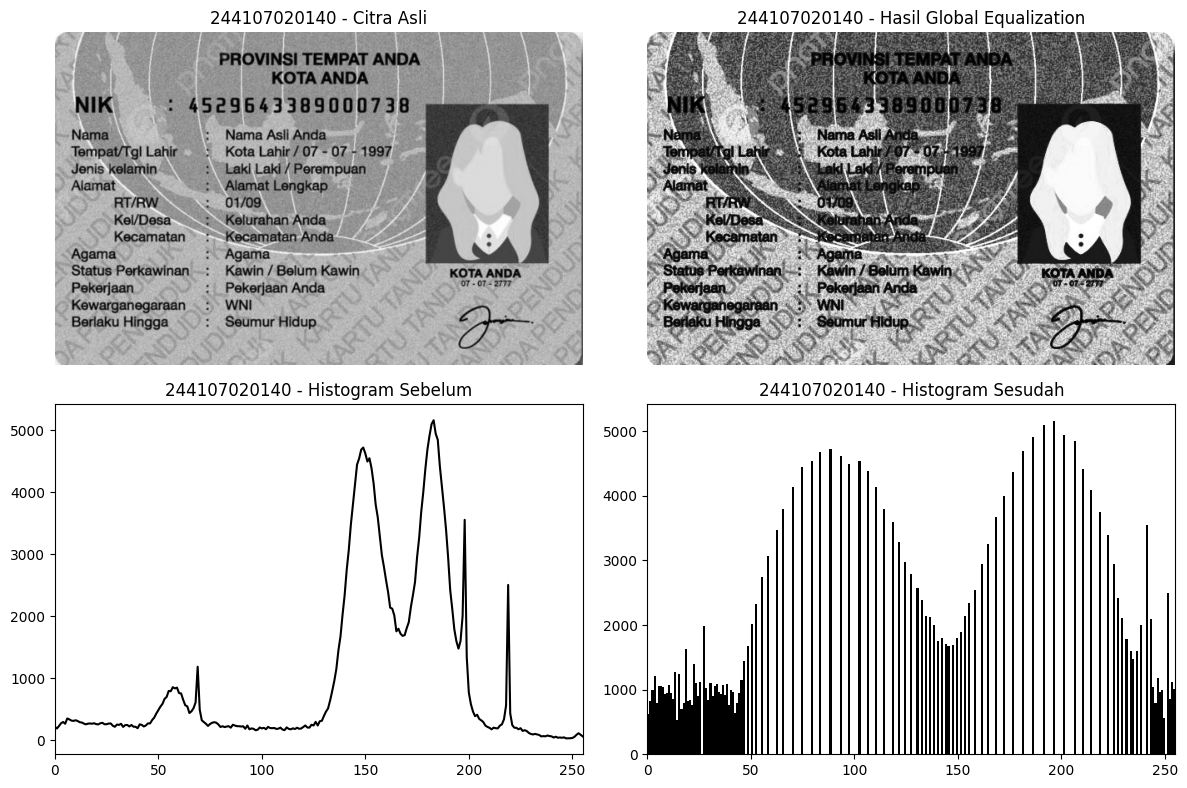

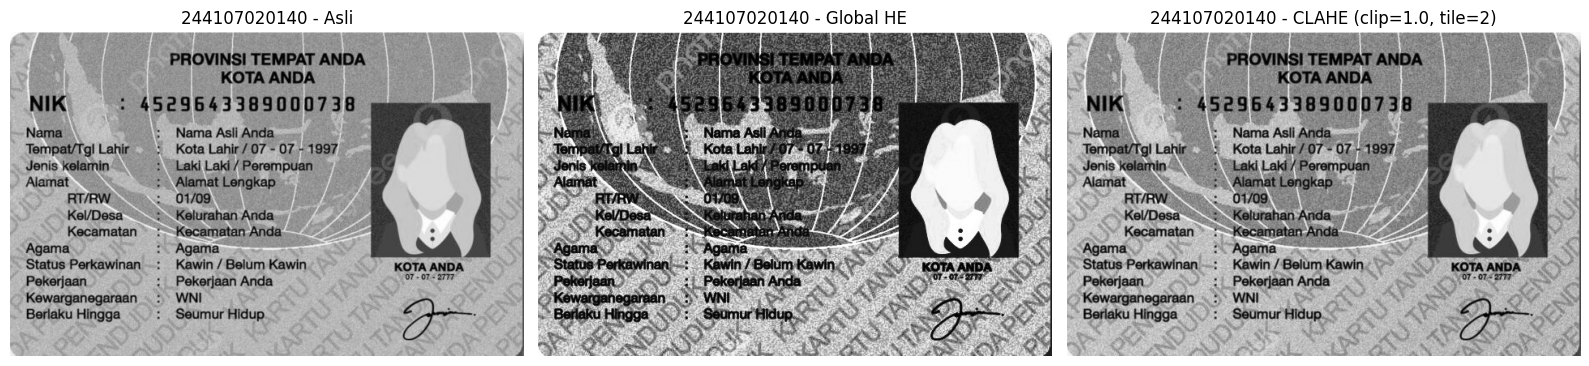

In [90]:
NIM = '244107020140'
N = int(NIM[-3:])
clip_val = round(1.0 + (N % 5) * 0.5, 1)
tile_val = (N % 4) + 2

path_ktp = '/content/drive/MyDrive/pcvk_2026/ktp.jpg'
img_asli = cv.imread(path_ktp, cv.IMREAD_GRAYSCALE)

hist_asli = np.zeros(256, dtype=np.int64)
for y in range(img_asli.shape[0]):
    for x in range(img_asli.shape[1]):
        hist_asli[img_asli[y, x]] += 1

cdf = np.cumsum(hist_asli)
cdf_norm = cdf / img_asli.size
K = np.round(255 * cdf_norm).astype(np.uint8)
img_manual = K[img_asli]

img_global = cv.equalizeHist(img_asli)

psnr_val = cv.PSNR(img_asli, img_global)
print("=== HASIL EVALUASI E2 NOMOR 1 ===")
print(f"Nilai PSNR (Citra Asli vs Global HE): {psnr_val:.2f} dB")

fig, axs = plt.subplots(2, 2, figsize=(12, 8))

axs[0, 0].imshow(img_asli, cmap='gray')
axs[0, 0].set_title(f"{NIM} - Citra Asli")
axs[0, 0].axis('off')

axs[0, 1].imshow(img_global, cmap='gray')
axs[0, 1].set_title(f"{NIM} - Hasil Global Equalization")
axs[0, 1].axis('off')

axs[1, 0].plot(hist_asli, color='black')
axs[1, 0].set_title(f"{NIM} - Histogram Sebelum")
axs[1, 0].set_xlim([0, 255])

axs[1, 1].hist(img_global.ravel(), bins=256, range=[0, 256], color='black')
axs[1, 1].set_title(f"{NIM} - Histogram Sesudah")
axs[1, 1].set_xlim([0, 255])

plt.tight_layout()
plt.show()

clahe_nim = cv.createCLAHE(clipLimit=PARAM['clip'], tileGridSize=(PARAM['tile'], PARAM['tile']))
img_clahe_nim = clahe_nim.apply(img_asli)

fig, axs = plt.subplots(1, 3, figsize=(16, 5))
axs[0].imshow(img_asli, cmap='gray')
axs[0].set_title(f"{NIM} - Asli")
axs[0].axis('off')

axs[1].imshow(img_global, cmap='gray')
axs[1].set_title(f"{NIM} - Global HE")
axs[1].axis('off')

axs[2].imshow(img_clahe_nim, cmap='gray')
axs[2].set_title(f"{NIM} - CLAHE (clip={clip_val}, tile={tile_val})")
axs[2].axis('off')

plt.tight_layout()
plt.show()


### Analisis PSNR

Nilai PSNR antara citra asli dan citra hasil histogram equalization
menurun karena proses equalization mengubah nilai intensitas piksel
dari citra asli. PSNR mengukur perbedaan numerik antara dua citra,
bukan tingkat keterbacaan objek atau teks pada citra.

Oleh karena itu, meskipun citra hasil equalization terlihat lebih jelas
dan teks lebih mudah dibaca, perubahan nilai piksel tersebut dapat
menyebabkan nilai PSNR menjadi lebih rendah.

Dengan demikian, PSNR kurang tepat digunakan sebagai satu-satunya
ukuran untuk menilai keterbacaan citra. Penilaian keterbacaan juga
perlu mempertimbangkan kualitas visual dan kejelasan informasi pada
citra.

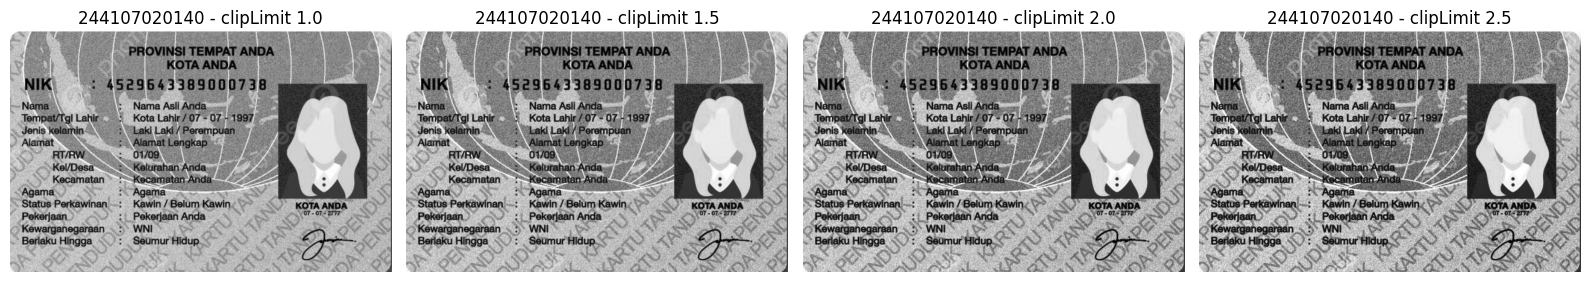

In [91]:
variasi_clip = [
    PARAM['clip'],
    PARAM['clip'] + 0.5,
    PARAM['clip'] + 1.0,
    PARAM['clip'] + 1.5
]

fig, axs = plt.subplots(1, 4, figsize=(16, 4))

for ax, clip in zip(axs, variasi_clip):

    clahe = cv.createCLAHE(
        clipLimit=clip,
        tileGridSize=(PARAM['tile'], PARAM['tile'])
    )

    hasil = clahe.apply(img_asli)

    ax.imshow(hasil, cmap='gray')
    ax.set_title(f'{NIM} - clipLimit {clip}')
    ax.axis('off')

plt.tight_layout()
plt.show()

### Pemilihan clipLimit

Berdasarkan hasil percobaan, clipLimit = 2.0 dipilih karena
memberikan keterbacaan NIK dan nama yang lebih baik dibandingkan
nilai yang lebih rendah, sementara noise belum terlalu menonjol.
Pada clipLimit yang lebih tinggi, detail lokal semakin diperkuat
sehingga noise pada citra juga mulai terlihat.

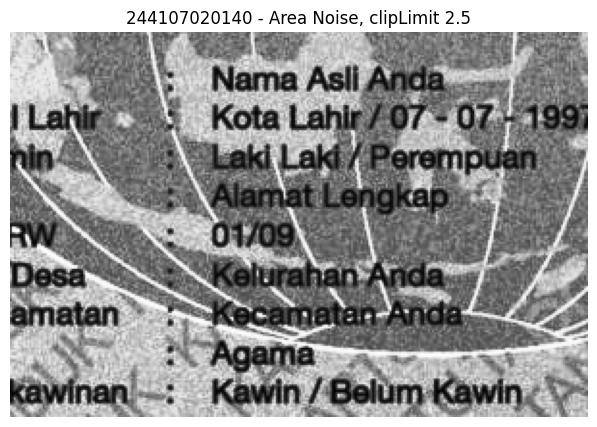

In [92]:
clip_noise = 2.5

clahe_noise = cv.createCLAHE(
    clipLimit=clip_noise,
    tileGridSize=(PARAM['tile'], PARAM['tile'])
)

hasil_noise = clahe_noise.apply(img_asli)

crop = hasil_noise[100:300, 100:400]

plt.figure(figsize=(8, 5))
plt.imshow(crop, cmap='gray')
plt.title(f'{NIM} - Area Noise, clipLimit {clip_noise}')
plt.axis('off')
plt.show()

In [93]:
def floyd_steinberg(gray, L=2):
    img = gray.astype(np.float32).copy()
    step = 255.0 / (L - 1)
    H, W = img.shape

    for y in range(H):
        for x in range(W):
            lama = img[y, x]
            baru = np.round(lama / step) * step
            img[y, x] = baru
            error = lama - baru

            if x + 1 < W:
                img[y, x + 1] += error * 7 / 16
            if x > 0 and y + 1 < H:
                img[y + 1, x - 1] += error * 3 / 16
            if y + 1 < H:
                img[y + 1, x] += error * 5 / 16
            if x + 1 < W and y + 1 < H:
                img[y + 1, x + 1] += error * 1 / 16

    return np.clip(img, 0, 255).astype(np.uint8)

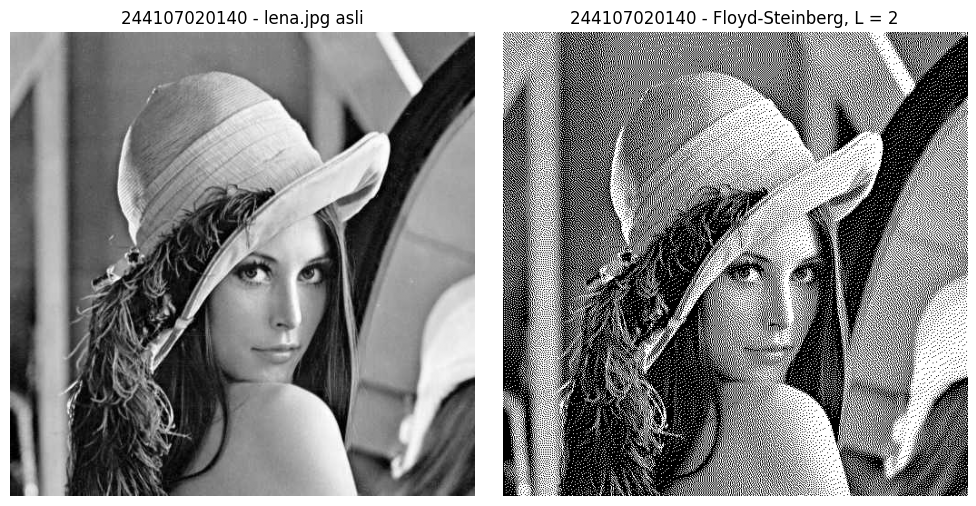

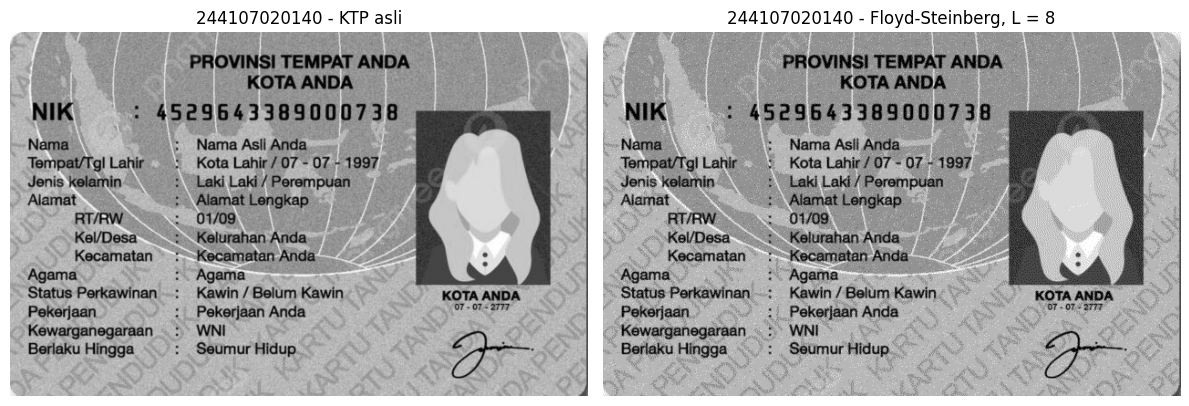

In [94]:
NIM = '244107020140'
N = int(NIM[-3:])
L_val = 2 ** ((N % 3) + 1)

CONTOH = '/content/drive/MyDrive/pcvk_2026/Images'
path_ktp = '/content/drive/MyDrive/pcvk_2026/ktp.jpg'

lena_asli = cv.imread(CONTOH + '/lena.jpg', cv.IMREAD_GRAYSCALE)
if lena_asli is not None:
    lena_dither = floyd_steinberg(lena_asli, L=2)

    fig, axs = plt.subplots(1, 2, figsize=(10, 5))
    axs[0].imshow(lena_asli, cmap='gray')
    axs[0].set_title(f"{NIM} - lena.jpg asli")
    axs[0].axis('off')

    axs[1].imshow(lena_dither, cmap='gray')
    axs[1].set_title(f"{NIM} - Floyd-Steinberg, L = 2")
    axs[1].axis('off')
    plt.tight_layout()
    plt.show()

ktp_asli = cv.imread(path_ktp, cv.IMREAD_GRAYSCALE)
ktp_dither = floyd_steinberg(ktp_asli, L=L_val)

fig, axs = plt.subplots(1, 2, figsize=(12, 5))
axs[0].imshow(ktp_asli, cmap='gray')
axs[0].set_title(f"{NIM} - KTP asli")
axs[0].axis('off')

axs[1].imshow(ktp_dither, cmap='gray')
axs[1].set_title(f"{NIM} - Floyd-Steinberg, L = {L_val}")
axs[1].axis('off')
plt.tight_layout()
plt.show()

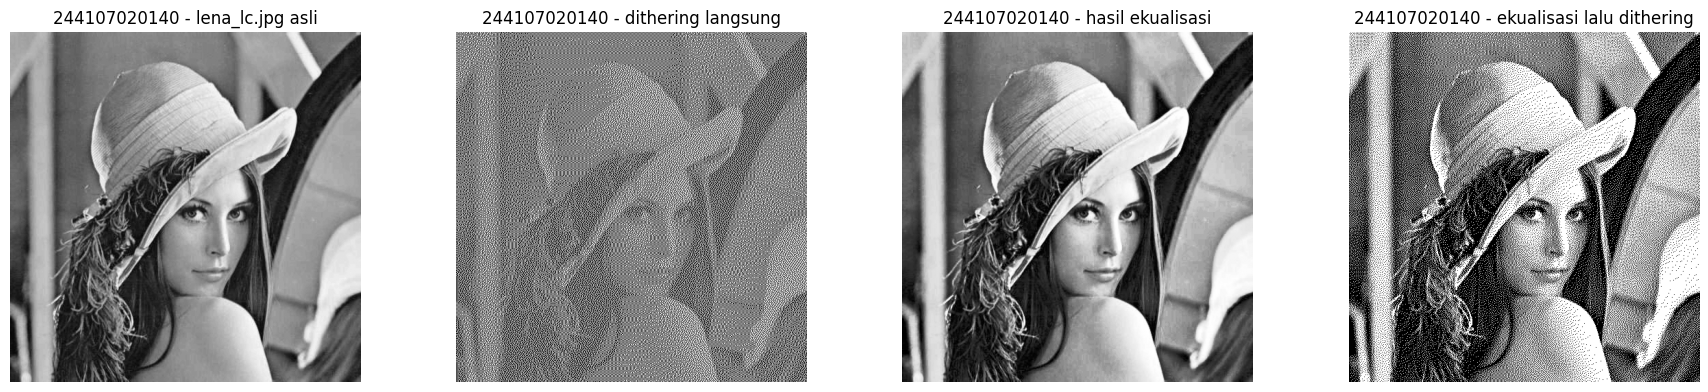

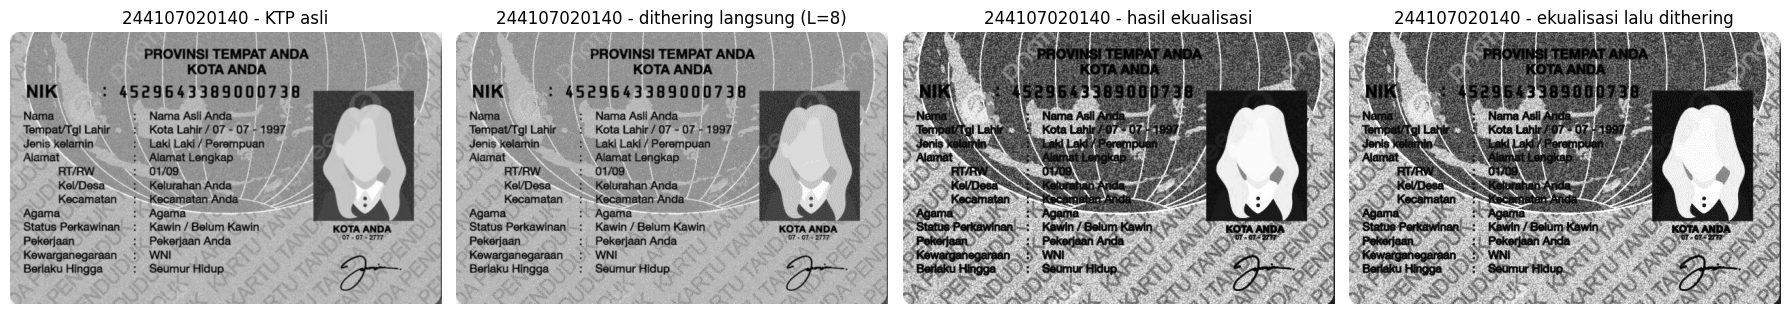

In [95]:
lena_lc = cv.imread(CONTOH + '/lena_lc.jpg', cv.IMREAD_GRAYSCALE)
if lena_lc is not None:
    lena_lc_dither_direct = floyd_steinberg(lena_lc, L=2)

    lena_lc_he = cv.equalizeHist(lena_lc)

    lena_lc_he_dither = floyd_steinberg(lena_lc_he, L=2)

    fig, axs = plt.subplots(1, 4, figsize=(18, 4))
    axs[0].imshow(lena_lc, cmap='gray')
    axs[0].set_title(f"{NIM} - lena_lc.jpg asli")
    axs[0].axis('off')

    axs[1].imshow(lena_lc_dither_direct, cmap='gray')
    axs[1].set_title(f"{NIM} - dithering langsung")
    axs[1].axis('off')

    axs[2].imshow(lena_lc_he, cmap='gray')
    axs[2].set_title(f"{NIM} - hasil ekualisasi")
    axs[2].axis('off')

    axs[3].imshow(lena_lc_he_dither, cmap='gray')
    axs[3].set_title(f"{NIM} - ekualisasi lalu dithering")
    axs[3].axis('off')

    plt.tight_layout()
    plt.show()

ktp_asli = cv.imread(path_ktp, cv.IMREAD_GRAYSCALE)

ktp_dither_direct = floyd_steinberg(ktp_asli, L=L_val)

ktp_he = cv.equalizeHist(ktp_asli)

ktp_he_dither = floyd_steinberg(ktp_he, L=L_val)

fig, axs = plt.subplots(1, 4, figsize=(18, 4))
axs[0].imshow(ktp_asli, cmap='gray')
axs[0].set_title(f"{NIM} - KTP asli")
axs[0].axis('off')

axs[1].imshow(ktp_dither_direct, cmap='gray')
axs[1].set_title(f"{NIM} - dithering langsung (L={L_val})")
axs[1].axis('off')

axs[2].imshow(ktp_he, cmap='gray')
axs[2].set_title(f"{NIM} - hasil ekualisasi")
axs[2].axis('off')

axs[3].imshow(ktp_he_dither, cmap='gray')
axs[3].set_title(f"{NIM} - ekualisasi lalu dithering")
axs[3].axis('off')

plt.tight_layout()
plt.show()